# House Prices - Advanced Regression Competition

### Completed and submitted by Tan Li Ting on 20 December 2025
### Achieved final RMSE of 0.14380

In [ ]:
# Import libraries
import pandas as pd
import math
import numpy as np
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import warnings
import logging

In [ ]:
# For better visualizations
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

In [ ]:
# Load training dataset
houses = pd.read_csv('train.csv')
display(houses)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
# Check dataset shape
print("Dataset shape: {}".format(houses.shape))

Dataset shape: (1460, 81)


In [ ]:
# Check dataset information
print("Dataset information:")
houses.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

# Exploratory Data Analysis

In [ ]:
# Create a copy
houses_eda = houses.copy()

In [ ]:
# Remove unnecessary variable 'Id'
houses_eda = houses_eda.drop('Id', axis=1)

In [ ]:
# Describe the dataset
houses_eda.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
# Check the percentage of nulls in each variable
pd.set_option('display.max_rows',None)

null_report = houses_eda.isnull().mean().sort_values(ascending=False) * 100
print(null_report)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageQual        5.547945
GarageType        5.547945
GarageFinish      5.547945
GarageCond        5.547945
GarageYrBlt       5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtQual          2.534247
BsmtFinType1      2.534247
BsmtCond          2.534247
MasVnrArea        0.547945
Electrical        0.068493
BldgType          0.000000
Neighborhood      0.000000
LandSlope         0.000000
Condition2        0.000000
Condition1        0.000000
LandContour       0.000000
LotShape          0.000000
Street            0.000000
LotArea           0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotConfig         0.000000
Utilities         0.000000
HouseStyle        0.000000
Foundation        0.000000
ExterQual         0.000000
ExterCond         0.000000
BsmtUnfSF         0.000000
T

Since some variables are missing most of their data, they should be removed to reduce noise in the model.

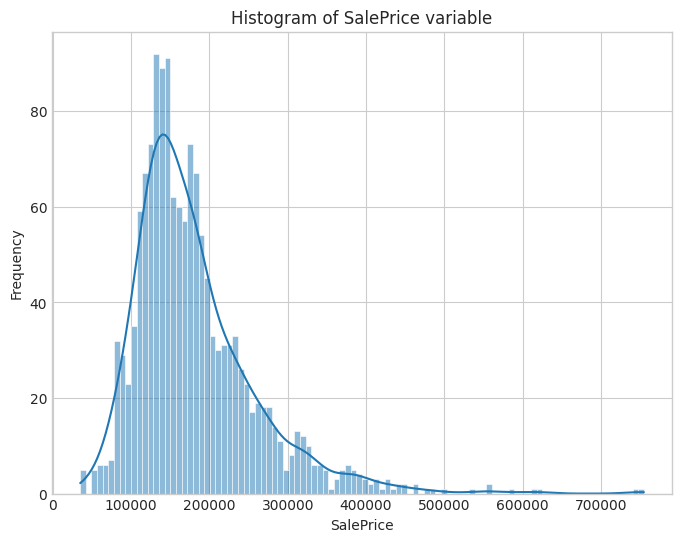

In [ ]:
# Display the distribution of 'SalePrice' variable
plt.figure(figsize=(8,6))
sns.histplot(houses_eda['SalePrice'], bins=100, kde=True)
plt.title('Histogram of SalePrice variable')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Check skewness of 'SalePrice' variable
houses_eda['SalePrice'].skew()

np.float64(1.8828757597682129)

Since the skewness of the target variable is high (greater than 1), it should be log transformed for the model.

In [ ]:
# Select numerical variables for histogram distribution
numvar = houses_eda.select_dtypes(include = ['int64','float64'])

<Figure size 800x600 with 0 Axes>

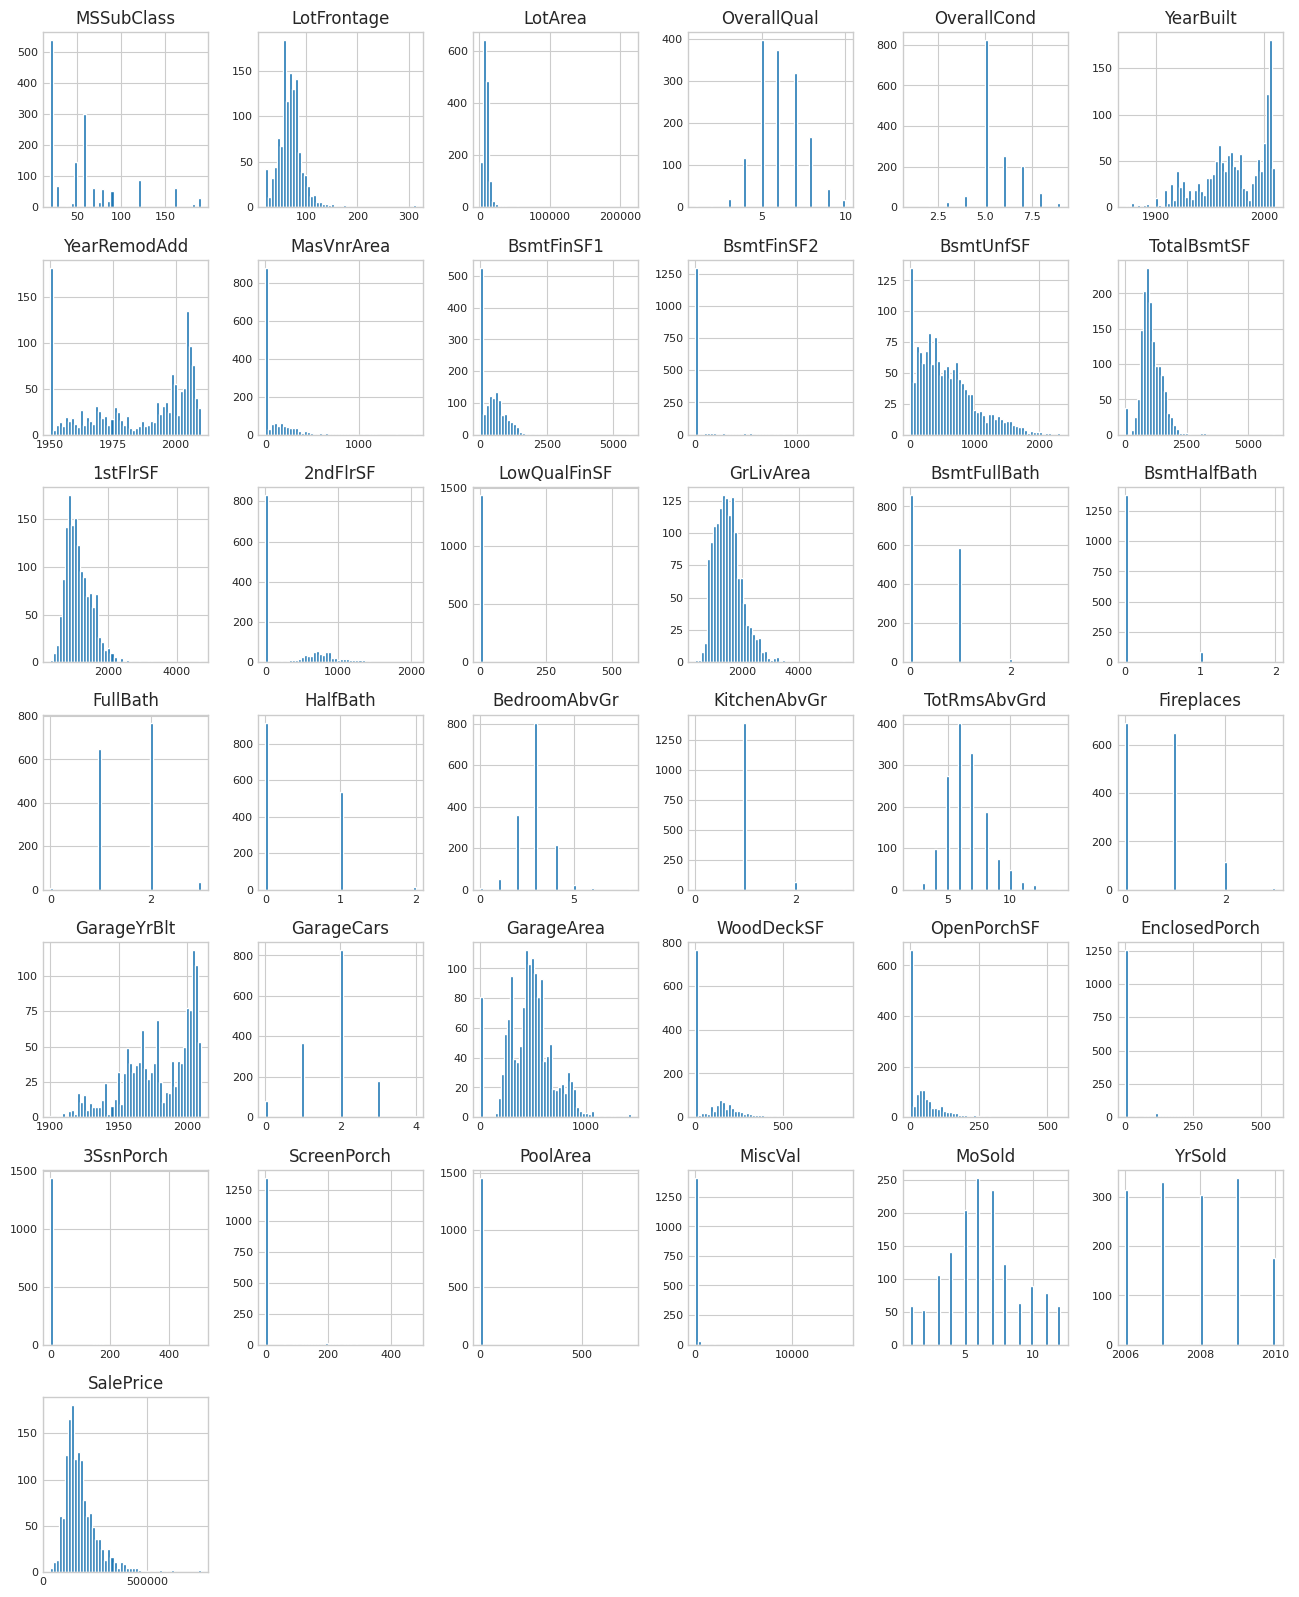

In [ ]:
# Display the distribution of numerical variables
plt.figure(figsize = (8,6))
numvar.hist(figsize=(16,20), bins=50, xlabelsize=8, ylabelsize=8)
plt.show()

In [ ]:
# Check the correlation between numerical variables and 'SalePrice' variable
targetvar = 'SalePrice'
features = [col for col in houses_eda.columns if col != targetvar]

for feature in features:
  if houses_eda[feature].dtype != 'object':
    temp_df = houses_eda[[feature, targetvar]].copy()
    temp_df.dropna(inplace=True)
    corr, p_value = stats.pearsonr(temp_df[feature], temp_df[targetvar])
    print(f"Feature: {feature:12} | r-value: {corr:.4f} | p-value: {p_value:.4f}")

Feature: MSSubClass   | r-value: -0.0843 | p-value: 0.0013
Feature: LotFrontage  | r-value: 0.3518 | p-value: 0.0000
Feature: LotArea      | r-value: 0.2638 | p-value: 0.0000
Feature: OverallQual  | r-value: 0.7910 | p-value: 0.0000
Feature: OverallCond  | r-value: -0.0779 | p-value: 0.0029
Feature: YearBuilt    | r-value: 0.5229 | p-value: 0.0000
Feature: YearRemodAdd | r-value: 0.5071 | p-value: 0.0000
Feature: MasVnrArea   | r-value: 0.4775 | p-value: 0.0000
Feature: BsmtFinSF1   | r-value: 0.3864 | p-value: 0.0000
Feature: BsmtFinSF2   | r-value: -0.0114 | p-value: 0.6640
Feature: BsmtUnfSF    | r-value: 0.2145 | p-value: 0.0000
Feature: TotalBsmtSF  | r-value: 0.6136 | p-value: 0.0000
Feature: 1stFlrSF     | r-value: 0.6059 | p-value: 0.0000
Feature: 2ndFlrSF     | r-value: 0.3193 | p-value: 0.0000
Feature: LowQualFinSF | r-value: -0.0256 | p-value: 0.3282
Feature: GrLivArea    | r-value: 0.7086 | p-value: 0.0000
Feature: BsmtFullBath | r-value: 0.2271 | p-value: 0.0000
Feature: B

As the p-values for the variables 'BsmtFinSF2', 'LowQualFinSF', 'LowQualFinSF', 'BsmtHalfBath', 'MiscVal', 'MoSold' and 'YrSold' are higher than 0.05, they will be removed as they are not as significant to the changes in 'SalePrice'.

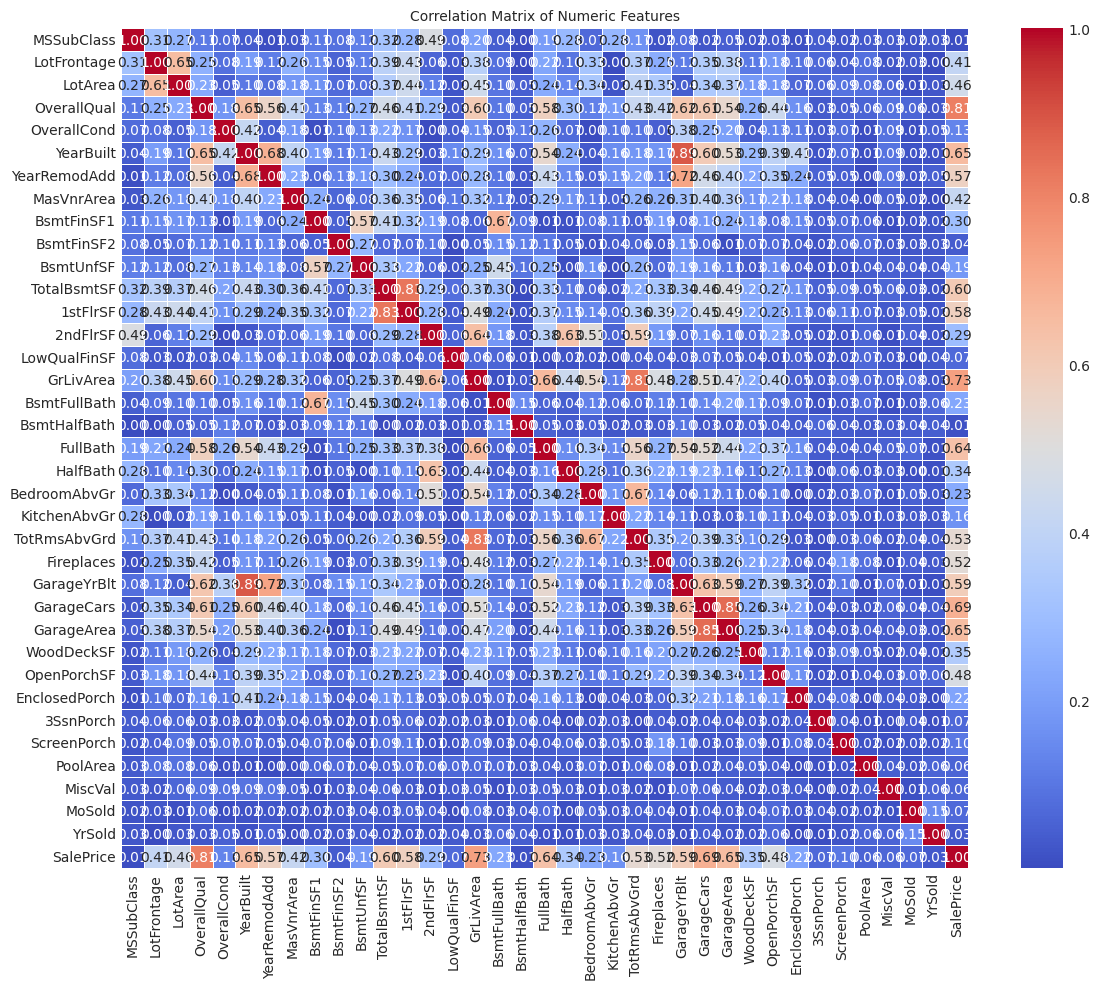

In [ ]:
# Select numeric columns
numvar = houses_eda.select_dtypes(include=['float64', 'int64']).columns

# Create correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = houses_eda[numvar].corr(method='spearman').abs()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Select categorical variables for histogram distribution
catvar = houses_eda.select_dtypes(include = ['object'])

In [ ]:
for var in catvar.columns:
  formula = f'SalePrice ~ C({var})'
  lm = ols(formula, data=houses_eda).fit()
  anova_results = anova_lm(lm)
  print(anova_results.loc[f'C({var})',['F','PR(>F)']])

F         4.384028e+01
PR(>F)    8.817634e-35
Name: C(MSZoning), dtype: float64
F         2.459290
PR(>F)    0.117049
Name: C(Street), dtype: float64
F         3.556206e+01
PR(>F)    4.899826e-08
Name: C(Alley), dtype: float64
F         4.013285e+01
PR(>F)    6.447524e-25
Name: C(LotShape), dtype: float64
F         1.285019e+01
PR(>F)    2.742217e-08
Name: C(LandContour), dtype: float64
F         0.298804
PR(>F)    0.584717
Name: C(Utilities), dtype: float64
F         7.809954
PR(>F)    0.000003
Name: C(LotConfig), dtype: float64
F         1.958817
PR(>F)    0.141396
Name: C(LandSlope), dtype: float64
F          7.178487e+01
PR(>F)    1.558600e-225
Name: C(Neighborhood), dtype: float64
F         6.118017e+00
PR(>F)    8.904549e-08
Name: C(Condition1), dtype: float64
F         2.073899
PR(>F)    0.043426
Name: C(Condition2), dtype: float64
F         1.301108e+01
PR(>F)    2.056736e-10
Name: C(BldgType), dtype: float64
F         1.959500e+01
PR(>F)    3.376777e-25
Name: C(HouseStyle), dt

As the variables 'Street', 'Utilities', 'LandSlope', 'PoolQC' and 'MiscFeature' have p-values lower than 0.05, they are not significant to the changes in 'SalePrice', and hence should be removed from the model as well.

# Preprocessing

In [ ]:
# Create a copy of the training dataset
houses_model = houses.copy()

In [ ]:
# Log tranform the 'SalePrice' variable
houses_model['SalePrice_log'] = np.log1p(houses_model['SalePrice'])

In [ ]:
# Drop variables that are not required
columns_drop = ['Id','SalePrice']
houses_model = houses_model.drop(columns=columns_drop, axis=1)

# Tensorflow Analysis

## Baseline Model Setup

In [ ]:
# Randomise the test and train datasets
def split_dataset(dataset, test_ratio=0.30):
  testindices = np.random.rand(len(dataset)) < test_ratio
  return dataset[~testindices], dataset[testindices]

train_ds_pd, valid_ds_pd = split_dataset(houses_model)
print("{} examples in training, {} examples in testing.".format(len(train_ds_pd), len(valid_ds_pd)))

1046 examples in training, 414 examples in testing.


In [ ]:
label = 'SalePrice_log'
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label=label, task=tfdf.keras.Task.REGRESSION)
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label=label, task=tfdf.keras.Task.REGRESSION)

In [ ]:
# Create a baseline random forest model
baseline_model = tfdf.keras.RandomForestModel(
    task=tfdf.keras.Task.REGRESSION,
    random_seed=42,
    num_trees=1000
)

baseline_model.compile(metrics=["mse"])

Use /tmp/tmp30dcka5p as temporary training directory


## Baseline Model Training

In [ ]:
# Train the baseline model
baseline_model.fit(x=train_ds)

Reading training dataset...
Training dataset read in 0:00:00.970534. Found 1046 examples.
Training model...
Model trained in 0:00:11.123861
Compiling model...
Model compiled.


In [ ]:
# Visualise the model
tfdf.model_plotter.plot_model_in_colab(baseline_model,tree_idx=0,max_depth=3)

## Baseline Model Evaluation

### General evaluation

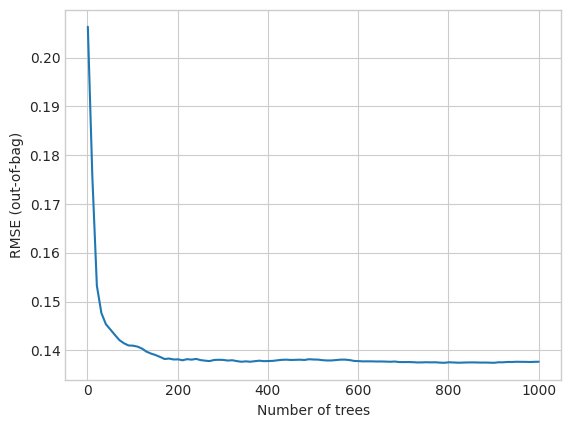

In [ ]:
# Evaluate the model's RMSE to check the fit
logs = baseline_model.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel('Number of trees')
plt.ylabel('RMSE (out-of-bag)')
plt.show()

In [ ]:
# General statistics of the dataset
inspector = baseline_model.make_inspector()
inspector.evaluation()

Evaluation(num_examples=1046, accuracy=None, loss=None, rmse=0.13768812990581725, ndcg=None, aucs=None, auuc=None, qini=None)

In [ ]:
# RMSE and MSE of the model
evaluation = baseline_model.evaluate(x=valid_ds,return_dict=True)
mse_value = evaluation['mse']
rmse_value = math.sqrt(mse_value)

print(f"MSE: {mse_value:.4f}")
print(f"RMSE: {rmse_value:.4f}")

1/1 [==============================] - 1s 509ms/step - loss: 0.0000e+00 - mse: 0.0182
MSE: 0.0182
RMSE: 0.1351


### Variable importance evaluation

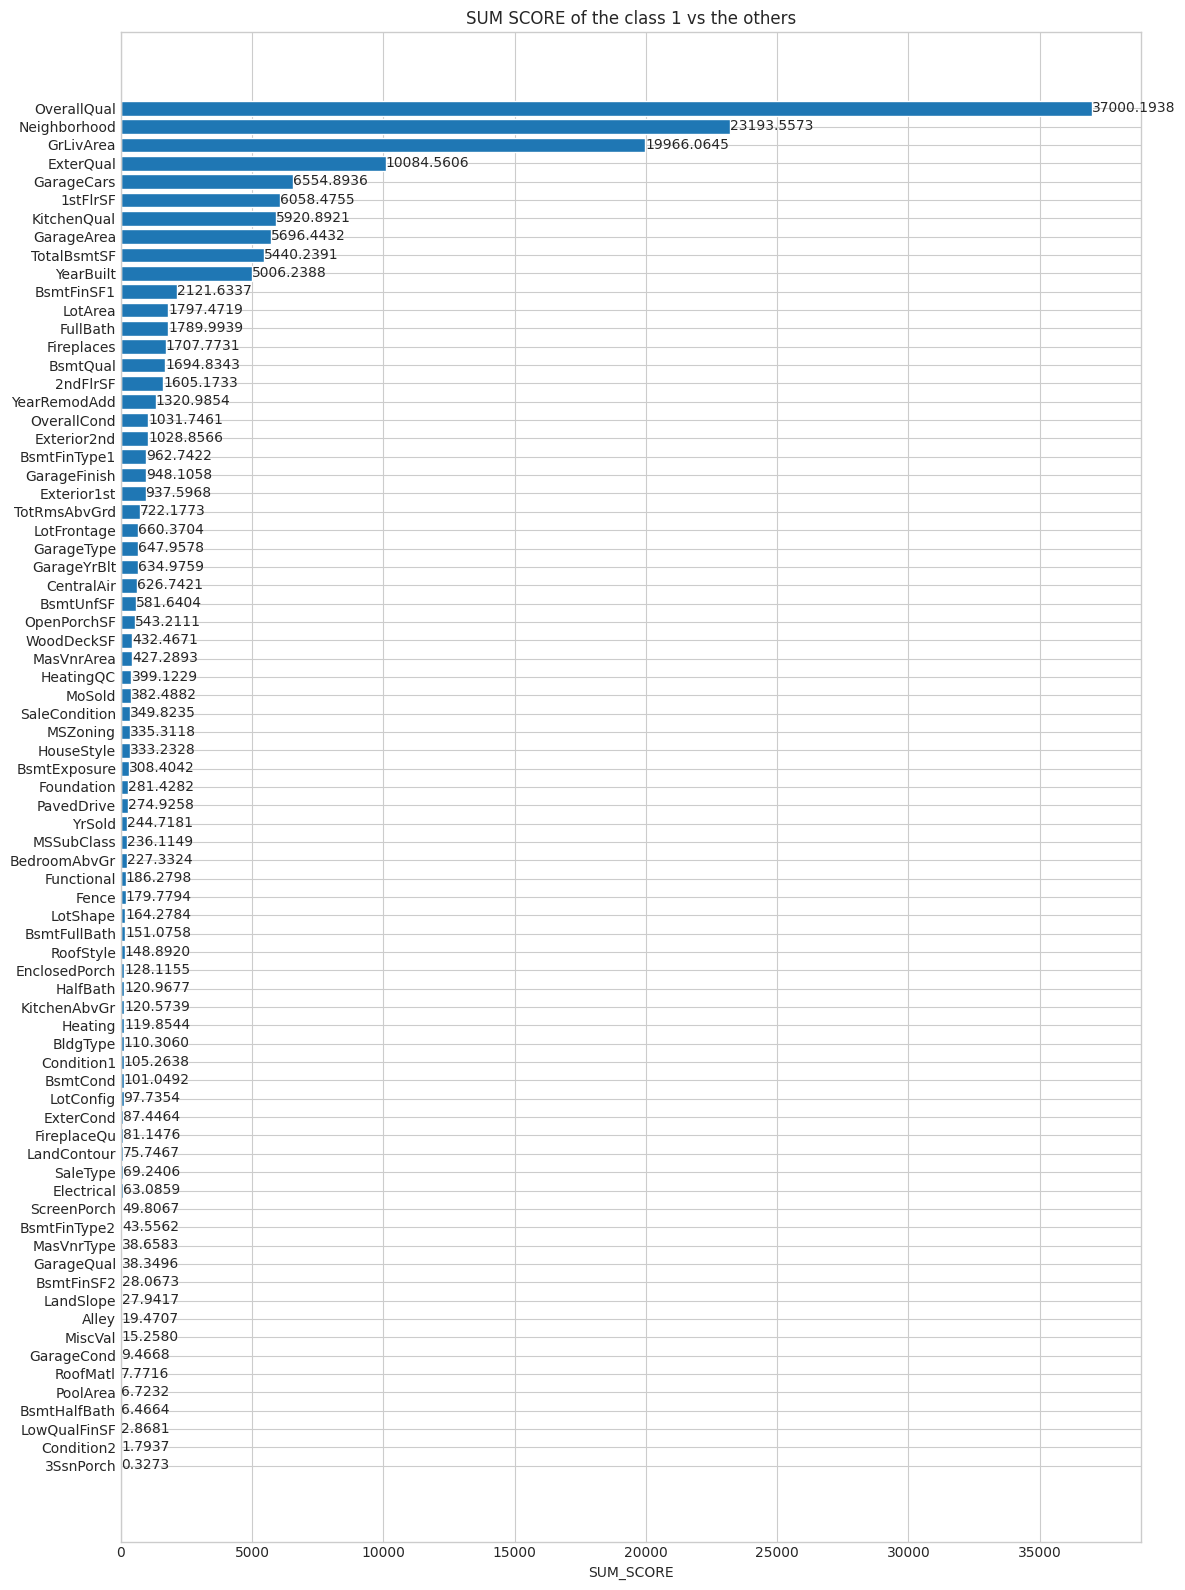

In [ ]:
# Plot the SUM_SCORE variable importance
plt.figure(figsize=(12,16))

checkimportances = inspector.variable_importances()["SUM_SCORE"]

feature_names = [vi[0].name for vi in variable_importances]
feature_importances = [vi[1] for vi in variable_importances]
feature_ranks = range(len(feature_names))

bar = plt.barh(feature_ranks,feature_importances,label=[str(x) for x in feature_ranks])
plt.yticks(feature_ranks,feature_names)
plt.gca().invert_yaxis()

for importance, patch in zip(feature_importances,bar.patches):
  plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{importance:.4f}", va='top')

plt.xlabel(variable_importance_metric)
plt.title('SUM SCORE of the class 1 vs the others')
plt.tight_layout()
plt.show()

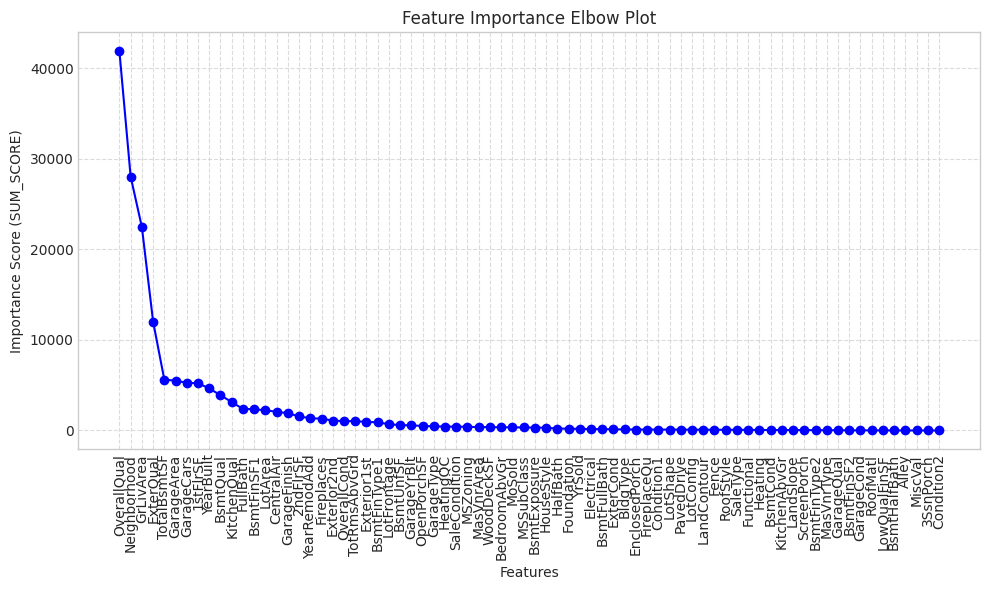

In [ ]:
# Check for the highest variable importance
feature_names = [item[0].name for item in checkimportances]
feature_scores = [item[1] for item in checkimportances]

plt.figure(figsize=(10, 6))
plt.plot(feature_names, feature_scores, marker='o', linestyle='-', color='b')
plt.xticks(rotation=90)
plt.ylabel("Importance Score (SUM_SCORE)")
plt.xlabel("Features")
plt.title("Feature Importance Elbow Plot")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 376ms/step - loss: 0.0000e+00 - mse: 0.0182


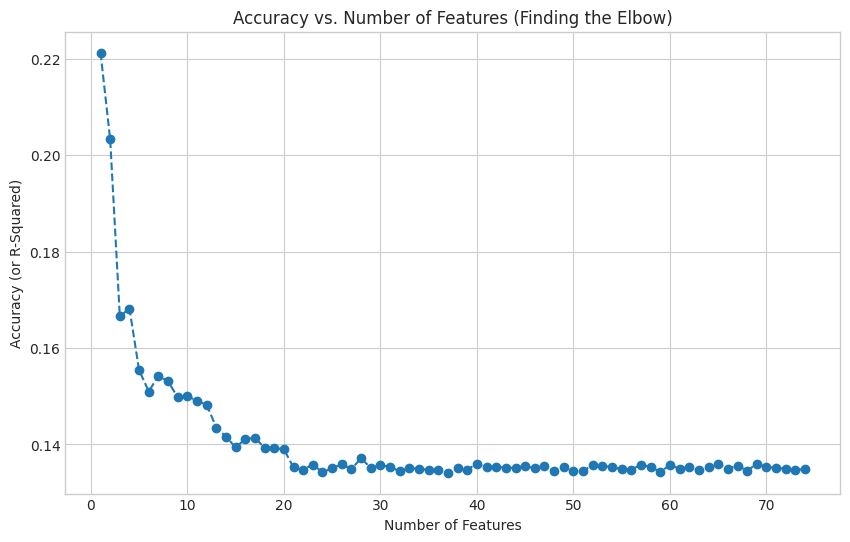

In [ ]:
# Sort features by importance score (highest to lowest)
sorted_features = [item[0].name for item in checkimportances]

accuracies = []
feature_counts = range(1, len(sorted_features) + 1)

# 2. Iteratively train models adding one feature at a time
for i in feature_counts:
    topfeatures = sorted_features[:i]
    label = 'SalePrice_log'
    train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd[topfeatures + [label]], label=label, task=tfdf.keras.Task.REGRESSION)
    valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd[topfeatures + [label]], label=label, task=tfdf.keras.Task.REGRESSION)
    temp_model = tfdf.keras.RandomForestModel(
    task=tfdf.keras.Task.REGRESSION,
    random_seed=42,
    num_trees=300,
    verbose=0
)
    temp_model.compile(metrics=["mse"])
    temp_model.fit(x=train_ds)
    evaluation = temp_model.evaluate(valid_ds,return_dict=True)
    temp_rmse = math.sqrt(evaluation['mse'])
    accuracies.append(temp_rmse)
    pass

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(feature_counts, accuracies, marker='o', linestyle='--')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy (or R-Squared)')
plt.title('Accuracy vs. Number of Features (Finding the Elbow)')
plt.grid(True)
plt.show()

Since the rmse value does not improve much after 21 variables, the optimised model will be using only the top 20 variables.

## Optimised Model Preprocessing

In [ ]:
# Create a new copy of dataset
houses_opmodel = houses.copy()

In [ ]:
# Log tranform the 'SalePrice' variable
houses_opmodel['SalePrice_log'] = np.log1p(houses_opmodel['SalePrice'])

In [ ]:
# Randomise the training and testing datasets
train_pd_opmodel, test_pd_opmodel = split_dataset(houses_opmodel)
print("{} examples in training, {} examples in testing.".format(len(train_pd_opmodel), len(test_pd_opmodel)))

1016 examples in training, 444 examples in testing.


In [ ]:
# Set up training and testing datasets
topfeatures = [item[0].name for item in checkimportances[:21]]

label = 'SalePrice_log'
train_opmodel = tfdf.keras.pd_dataframe_to_tf_dataset(train_pd_opmodel[topfeatures + [label]], label=label, task=tfdf.keras.Task.REGRESSION)
test_opmodel = tfdf.keras.pd_dataframe_to_tf_dataset(test_pd_opmodel[topfeatures + [label]], label=label, task=tfdf.keras.Task.REGRESSION)

## Optimised Model

In [ ]:
# Set up optimised model's tuner specifications
tuner = tfdf.tuner.RandomSearch(num_trials=25)
tuner.choice("num_trees", [500, 1000])
tuner.choice("max_depth", [20, 30, -1])
tuner.choice("num_candidate_attributes", [10, 20, 30, 43])

In [ ]:
# Create the optimised random forest model
opmodel = tfdf.keras.RandomForestModel(
    task=tfdf.keras.Task.REGRESSION,
    tuner=tuner,
    # hyperparameter_template="benchmark_rank1",
    random_seed=42,
    features=[tfdf.keras.FeatureUsage(name=n) for n in topfeatures],
    exclude_non_specified_features=True)

opmodel.compile(metrics=["mse"])

Use /tmp/tmp3qcg7jy3 as temporary training directory


In [ ]:
# Train the optimised model
opmodel.fit(x=train_opmodel, verbose=0)

In [ ]:
# Show the best parameters
opmodel.summary()

Model: "random_forest_model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: REGRESSION
Label: "__LABEL"

Input Features (43):
	1stFlrSF
	2ndFlrSF
	BedroomAbvGr
	BsmtExposure
	BsmtFinSF1
	BsmtFinType1
	BsmtFullBath
	BsmtQual
	BsmtUnfSF
	CentralAir
	ExterQual
	Exterior1st
	Exterior2nd
	Fireplaces
	FullBath
	GarageArea
	GarageCars
	GarageFinish
	GarageType
	GarageYrBlt
	GrLivArea
	HeatingQC
	HouseStyle
	KitchenQual
	LotArea
	LotConfig
	LotFrontage
	MSSubClass
	MSZoning
	MasVnrArea
	MoSold
	Neighborhood
	OpenPorchSF
	OverallCond
	OverallQual
	SaleCondition
	SaleType
	TotRmsAbvGrd
	TotalBsmtSF
	WoodDeckSF
	YearBuilt
	YearRemodAdd
	YrSold

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.   "OverallQual"  0.27

In [ ]:
# Visualise the model
tfdf.model_plotter.plot_model_in_colab(opmodel,tree_idx=0,max_depth=3)

## Optimised Model Evaluation

### General Evaluation

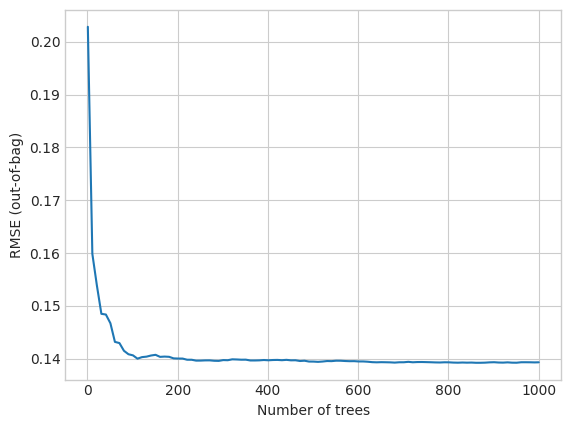

In [ ]:
# Evaluate the model's RMSE to check the fit
logs = opmodel.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel('Number of trees')
plt.ylabel('RMSE (out-of-bag)')
plt.show()

In [ ]:
# General statistics of the dataset
inspector = opmodel.make_inspector()
inspector.evaluation()

Evaluation(num_examples=1016, accuracy=None, loss=None, rmse=0.13930471247212944, ndcg=None, aucs=None, auuc=None, qini=None)

In [ ]:
# RMSE and MSE of the model
evaluation = opmodel.evaluate(x=valid_ds,return_dict=True)
mse_value = evaluation['mse']
rmse_value = math.sqrt(mse_value)

print(f"MSE: {mse_value:.4f}")
print(f"RMSE: {rmse_value:.4f}")

1/1 [==============================] - 0s 417ms/step - loss: 0.0000e+00 - mse: 0.0088
MSE: 0.0088
RMSE: 0.0939


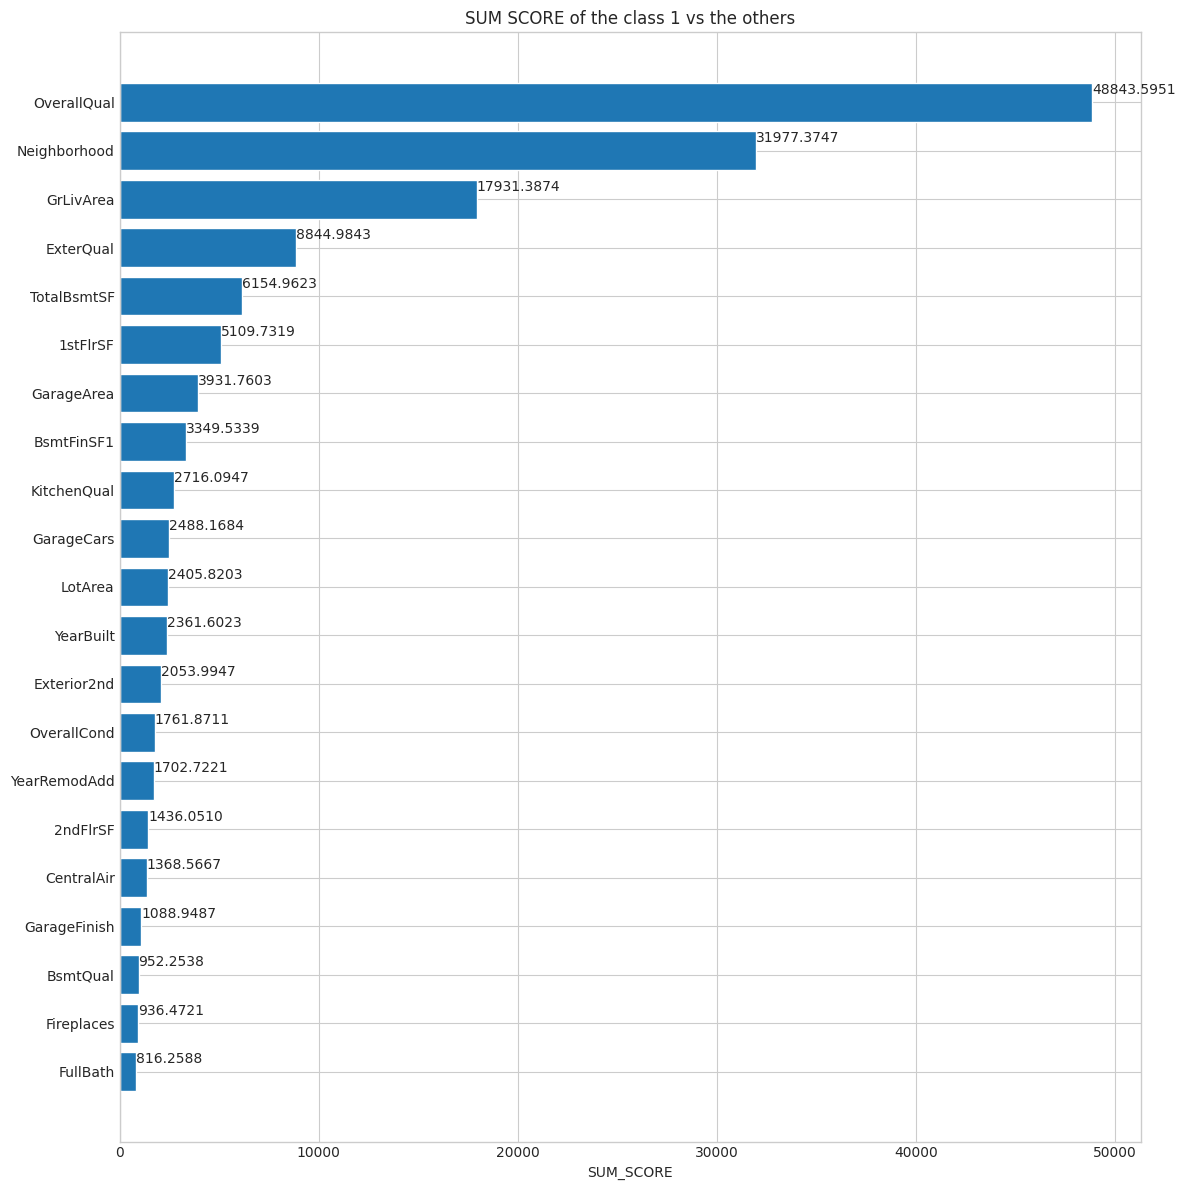

In [ ]:
# Plot the SUM_SCORE variable importance
plt.figure(figsize=(12,12))

variable_importance_metric = "SUM_SCORE"
variable_importances = inspector.variable_importances()[variable_importance_metric]

feature_names = [vi[0].name for vi in variable_importances]
feature_importances = [vi[1] for vi in variable_importances]
feature_ranks = range(len(feature_names))

bar = plt.barh(feature_ranks,feature_importances,label=[str(x) for x in feature_ranks])
plt.yticks(feature_ranks,feature_names)
plt.gca().invert_yaxis()

for importance, patch in zip(feature_importances,bar.patches):
  plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{importance:.4f}", va='top')

plt.xlabel(variable_importance_metric)
plt.title('SUM SCORE of the class 1 vs the others')
plt.tight_layout()
plt.show()

### Variable Evaluation

In [ ]:
inspector = opmodel.make_inspector()
print(f"Winning Hyperparameters: {inspector.tuning_logs()}")

Winning Hyperparameters:        score  evaluation_time   best  num_trees  max_depth  \
0  -0.144074         2.862314  False        500         -1   
1  -0.144071         6.040669  False        500         20   
2  -0.143935        12.220100  False       1000         -1   
3  -0.144074        15.033210  False        500         -1   
4  -0.143935        21.468945  False       1000         30   
5  -0.144071        24.276361  False        500         20   
6  -0.143932        29.880421  False       1000         20   
7  -0.139317        34.966517  False       1000         20   
8  -0.144074        37.797601  False        500         30   
9  -0.143935        43.624543  False       1000         -1   
10 -0.144074        47.232275  False        500         -1   
11 -0.139305        51.597186   True       1000         -1   
12 -0.144074        54.608969  False        500         30   
13 -0.139408        57.214662  False        500         -1   
14 -0.143935        63.270850  False       10

# Model Application on testing data

In [ ]:
# Load testing data
testdata = pd.read_csv('test.csv')
test_modeldata = testdata.copy()

In [ ]:
# Preprocess the testing data
ids = test_modeldata['Id']

In [ ]:
# Predict the 'SalePrice' variable of the testing data
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_modeldata[topfeatures], task = tfdf.keras.Task.REGRESSION)
logprediction = opmodel.predict(test_ds)
saleprediction = np.expm1(logprediction)

2/2 [==============================] - 1s 60ms/step


In [ ]:
# Output the result in a dataframe
output = pd.DataFrame({'Id':ids,
                      'SalePrice':saleprediction.squeeze()})

output.head()

,Id,SalePrice
0,1461,128197.046875
1,1462,153192.187500
2,1463,174989.656250
3,1464,182724.937500
4,1465,194740.640625


In [ ]:
# Export as a csv file for competition submission
output.to_csv('results.csv', index=False, header=True)